In [1]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.5 MB/s eta 0:00:00


In [2]:
import copy
import torch as th
import torch.nn as nn
import torch.optim as optim
import torchmetrics as M
from datasets import load_dataset
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

In [3]:
# Русский: задаю основные гиперпараметры обучения, пути сохранения модели и устройство вычислений
# English: defining training hyperparameters, model save paths, and the computation device

DATASET_NAME = "zh-plus/tiny-imagenet"
NUM_CLASSES = 200
INPUT_SIZE = 128

BATCH_SIZE = 512
NUM_EPOCH = 30
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.1

SEED = 42
CLASSIFIER_FILE_NAME = "resnet10ti_classifier_best_checkpoint.pth"
EXTRACTOR_FILE_NAME = "resnet10ti_extractor.pth"

DEVICE = th.device("cuda" if th.cuda.is_available() else "cpu")

In [4]:
# Русский: создаю PyTorch-обертку над Tiny ImageNet из Hugging Face для применения torchvision transforms
# English: creating a PyTorch wrapper around Hugging Face Tiny ImageNet to apply torchvision transforms

class HFTinyImageNetDataset(Dataset):
    def __init__(self, hf_dataset, transform=None) -> None:
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self) -> int:
        return len(self.hf_dataset)

    def __getitem__(self, index: int):
        item = self.hf_dataset[index]
        image = item["image"]
        label = int(item["label"])
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label

In [5]:
# Русский: реализую residual-блок с двумя свертками 3×3 и shortcut-соединением
# English: implementing a residual block with two 3×3 convolutions and a shortcut connection

class ResNet10TIBasicBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: th.Tensor) -> th.Tensor:
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity
        out = self.relu(out)
        return out

In [6]:
# Русский: определяю компактную ResNet-подобную модель для Tiny ImageNet с выходом на 200 классов
# English: defining a compact ResNet-like model for Tiny ImageNet with a 200-class output

class ResNet10TI(nn.Module):
    def __init__(self, num_classes: int = 200) -> None:
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.stage1 = ResNet10TIBasicBlock(64, 64, stride=1)
        self.stage2 = ResNet10TIBasicBlock(64, 128, stride=2)
        self.stage3 = ResNet10TIBasicBlock(128, 256, stride=2)
        self.stage4 = ResNet10TIBasicBlock(256, 256, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x: th.Tensor) -> th.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x

In [7]:
# Русский: задаю train и validation preprocessing для приведения изображений к размеру 128×128
# English: defining train and validation preprocessing to convert images to 128×128 input size

mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    T.Resize((144, 144)),
    T.RandomCrop((INPUT_SIZE, INPUT_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03,
    ),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

valid_transform = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

In [8]:
# Русский: загружаю Tiny ImageNet и создаю обучающий и валидационный датасеты
# English: loading Tiny ImageNet and creating training and validation datasets

raw_dataset = load_dataset(DATASET_NAME)

train_dataset = HFTinyImageNetDataset(
    raw_dataset["train"],
    transform=train_transform,
)

valid_dataset = HFTinyImageNetDataset(
    raw_dataset["valid"],
    transform=valid_transform,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-1359597a978bc4(…):   0%|          | 0.00/146M [00:00<?, ?B/s]

data/valid-00000-of-00001-70d52db3c749a9(…):   0%|          | 0.00/14.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [9]:
# Русский: реализую цикл обучения и валидации с сохранением лучшей модели по best_metric
# English: implementing the training and validation loop with best-model saving by best_metric

def train_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: th.optim.Optimizer,
    metric: M.Metric,
    file_name: str,
    train: Dataset,
    test: Dataset,
    batch_size: int,
    num_epoch: int,
    scheduler=None,
    device: str | th.device | None = None,
) -> tuple[list[float], list[float]]:
    th.manual_seed(SEED)

    if device is None:
        device = th.device("cuda" if th.cuda.is_available() else "cpu")
    else:
        device = th.device(device)

    loader = DataLoader(
        train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        prefetch_factor=2,
    )

    loader_test = DataLoader(
        test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        prefetch_factor=2,
    )

    model = model.to(device)
    criterion = criterion.to(device)
    metric = metric.to(device)

    scaler = GradScaler("cuda")

    best_metric = 0.0
    epoch_losses = []
    test_metrics = []

    progress = tqdm(
        range(1, num_epoch + 1),
        desc="Training",
        leave=True,
    )

    for epoch in progress:
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        if scheduler is not None:
            scheduler.step()

        epoch_loss /= len(loader)
        epoch_losses.append(epoch_loss)

        metric.reset()
        model.eval()

        with th.no_grad():
            for X_batch, y_batch in loader_test:
                X_batch = X_batch.to(device, non_blocking=True)
                y_batch = y_batch.to(device, non_blocking=True)
                with autocast("cuda"):
                    y_pred = model(X_batch)
                metric.update(y_pred, y_batch)

        test_metric = metric.compute().cpu().item()
        test_metrics.append(test_metric)

        saved_best = "no"

        if test_metric > best_metric:
            best_metric = test_metric
            th.save(model, file_name)
            saved_best = "yes"

        progress.set_postfix(
            epoch=f"{epoch}/{num_epoch}",
            loss=f"{epoch_loss:.4f}",
            valid_metric=f"{test_metric:.4f}",
            saved_best=saved_best,
        )

    return epoch_losses, test_metrics

In [10]:
# Русский: создаю модель, loss, optimizer, scheduler и метрику
# English: creating the model, loss, optimizer, scheduler and metric

model = ResNet10TI(num_classes=NUM_CLASSES)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCH,
    eta_min=1e-6,
)

metric = M.Accuracy(
    task="multiclass",
    num_classes=NUM_CLASSES,
)

sum([p.numel() for p in model.parameters()])

2523144

In [11]:
epoch_losses, valid_accuracy = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    metric=metric,
    file_name=CLASSIFIER_FILE_NAME,
    train=train_dataset,
    test=valid_dataset,
    batch_size=BATCH_SIZE,
    num_epoch=NUM_EPOCH,
    scheduler=scheduler,
    device=DEVICE,
)

Training:   0%|          | 0/30 [00:00<?, ?it/s]

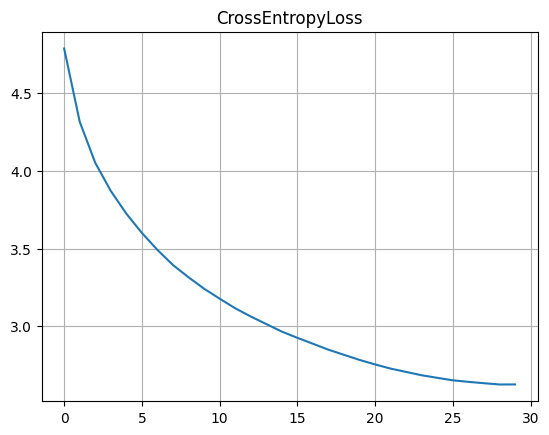

In [12]:
plt.title("CrossEntropyLoss")
plt.plot(epoch_losses)
plt.grid(True)
plt.show()

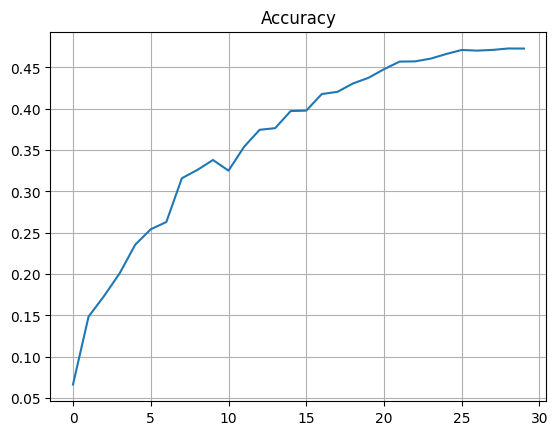

In [13]:
plt.title("Accuracy")
plt.plot(valid_accuracy)
plt.grid(True)
plt.show()

In [14]:
# Русский: заменяю классификатор fc на Identity и сохраняю модель для извлечения 256-мерных эмбеддингов
# English: replacing the fc classifier with Identity and saving the model for 256-dimensional embedding extraction

best_classifier = th.load(
    CLASSIFIER_FILE_NAME,
    map_location="cpu",
    weights_only=False,
)

best_classifier.eval()

extractor = copy.deepcopy(best_classifier)
extractor.fc = nn.Identity()
extractor.eval()

th.save(extractor, EXTRACTOR_FILE_NAME)

In [17]:
epoch_losses

[4.787153900886069,
 4.316506120623375,
 4.051506760169048,
 3.870488177756874,
 3.7241514179171347,
 3.60036916270548,
 3.4909237221795686,
 3.3937522951437504,
 3.314971545521094,
 3.2414030043446287,
 3.1774381326169383,
 3.1156312981430365,
 3.0626790073453165,
 3.014084041118622,
 2.9655266173031865,
 2.925308319987083,
 2.8872613432456036,
 2.848859488964081,
 2.8159466118228678,
 2.7831618214140135,
 2.7541261351838404,
 2.727271488734654,
 2.7058273882282022,
 2.6843764660309772,
 2.6679409061159407,
 2.651992282088922,
 2.642048017102845,
 2.6333324118536345,
 2.6251725384167264,
 2.6253536489545084]

In [18]:
valid_accuracy

[0.06650000065565109,
 0.1485999971628189,
 0.1736000031232834,
 0.20100000500679016,
 0.23559999465942383,
 0.25429999828338623,
 0.2630000114440918,
 0.3160000145435333,
 0.3260999917984009,
 0.33809998631477356,
 0.32519999146461487,
 0.3540000021457672,
 0.37459999322891235,
 0.3765999972820282,
 0.39730000495910645,
 0.3977999985218048,
 0.4178999960422516,
 0.4205000102519989,
 0.43059998750686646,
 0.4375,
 0.4478999972343445,
 0.4571000039577484,
 0.45739999413490295,
 0.46070000529289246,
 0.46630001068115234,
 0.47119998931884766,
 0.47040000557899475,
 0.47130000591278076,
 0.4729999899864197,
 0.47290000319480896]